# OpenPOPCON ITER example

The ITER baseline inductive scenario: 15 MA, 5.3 T, 500 MW of fusion power at
Q = 10. Machine parameters come from the ITER Physics Basis and Progress in
the ITER Physics Basis (references [7] in the repository README).

This example uses parabolic profiles rather than a gEQDSK, which keeps `R`,
`a`, `kappa`, `delta` and `I_P` free for `POPCON_scan` to vary.

In [1]:
import numpy as np
import openpopcon as op

## Setup and run

`settingsfile` holds the machine and algorithm settings, `plotsettingsfile`
the contour levels and axes. Both are read from this directory.

The numerics are compiled with numba the first time they run, so the first
solve in a fresh kernel takes a few seconds longer than the rest.

In [2]:
settingsfile = "./POPCON_input_example.yaml"
plotsettingsfile = "./plotsettings.yml"

pc = op.POPCON(settingsfile=settingsfile, plotsettingsfile=plotsettingsfile)
pc.run_POPCON()

Impurity fractions = [0.025     0.0079697 0.        0.        0.        0.       ] calculated from Zeff_target.
Setting up algorithm object
Solving power balance equations


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Power balance solutions found. Populating output arrays.
350 of 2500 grid points (14.0%) have no physical solution and are masked in the plot:
     350  impurity radiation exceeds the confinement loss
590 of 2500 grid points need no auxiliary heating (P_aux cannot be less than zero, setting P_aux = 0).


## Plotting

Plotting Paux with levels [ 10.  20.  50.  73. 100. 200. 500.] and options ['r', 3, '$P_{aux}$', 12, '%.2d']
Plotting Pfusion with levels [  50.  100.  200.  500. 1000. 2000.] and options ['k', 2, '$P_{fus}$', 12, '%.2d']
Plotting Prad with levels [ 10.  50. 100. 200.] and options ['purple', 2, '$P_{rad}$', 12, '%.2d']
Plotting Q with levels [  1.   2.   5.  10.  20.  50. 100.] and options ['orange', 2, '$Q$', 12, '%.f']
Plotting H98 with levels [0.99  0.995 1.    1.005 1.01 ] and options ['blue', 2, '$H_{98y2}$', 12, '%.1f']
Plotting betaN with levels [1.  1.8 2.5 3. ] and options ['forestgreen', 2, '$\\beta_N$', 12, '%.2f']


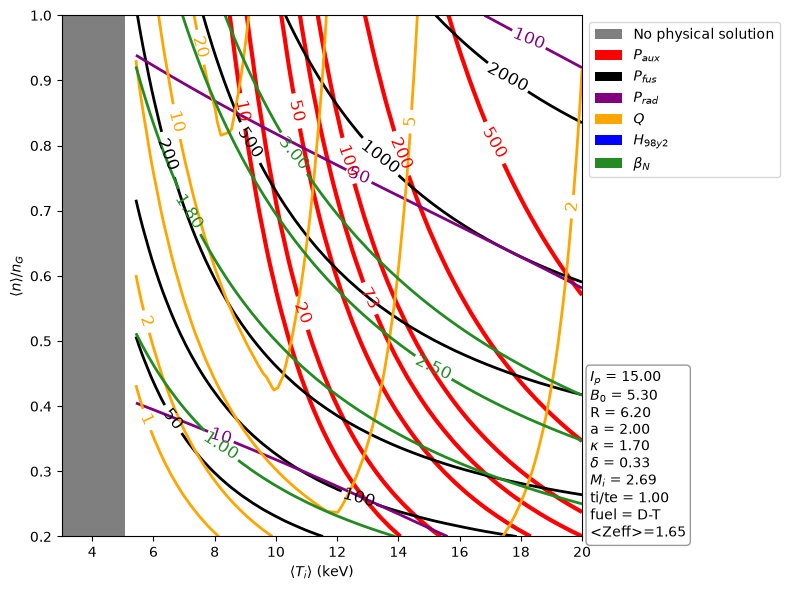

In [3]:
fig, ax = pc.plot()

### Checking against the design point

The baseline sits near 0.85 of the Greenwald density at a volume-averaged ion
temperature around 8.5 keV. The fusion power there should come out close to
the nominal 500 MW.

Q comes out higher than the nominal 10. That is expected rather than wrong:
ITER's Q = 10 point carries 50 MW of external heating for burn control, not
because 50 MW is the minimum required, and a 0-D balance with parabolic
profiles finds the ignition boundary nearby. Read the Q contours as
optimistic.

In [4]:
valid = pc.output.Paux < 99998.0
i = int(np.abs(pc.output.n_G_frac.values - 0.85).argmin())
j = int(np.abs(pc.output.T_i_avg.values - 8.5).argmin())
point = pc.output.isel(n_index=i, T_index=j)

print(f"n/n_G   = {float(point.n_G_frac):.2f}")
print(f"<T_i>   = {float(point.T_i_avg):.1f} keV")
print(f"P_fus   = {float(point.Pfusion):.0f} MW   (nominal 500)")
print(f"P_aux   = {float(point.Paux):.0f} MW")
print(f"Q       = {float(point.Q):.1f}")
print(f"beta_N  = {float(point.betaN):.2f}")

n/n_G   = 0.85
<T_i>   = 8.6 keV
P_fus   = 481 MW   (nominal 500)
P_aux   = 5 MW
Q       = 20.4
beta_N  = 2.62


## Scoping a single operating point

`single_point` solves one density/temperature pair and shows the profiles
behind it, which is the quickest way to see why a point on the POPCON sits
where it does.


Params:
n_i_average = 0.8981282498110913 x 10^20 m^-3
n_e_average = 1.015 x 10^20 m^-3
n_G = 1.194 x 10^20 m^-3
n_i_axis = 1.129 x 10^20 m^-3
n_e_axis = 1.276 x 10^20 m^-3
Ti_average = 8.5 keV
Ti_axis = 14.1 keV
Solution:
P_aux = 3.99 MW
P_fusion = 471.35 MW
P_SOL = 68.21 MW
P_load = 0.103 MW/m^2
P_ohmic = 18.977 MW
P_brems = 25.172 MW
P_synch = 3.703 MW
P_imprad = 20.503 MW
P_rad = 49.38 MW
P_heat = 88.72 MW
P_alpha = 94.27 MW
P_dd = 0.531 MW
P_dt = 470.82 MW
Wtot/TauE = 88.72 MW
f_rad = 0.420 
tauE = 3.754 s
Q = 20.526 
H89 = 2.22
H98 = 1.00
vloop = 1.2651 V
betaN = 2.600



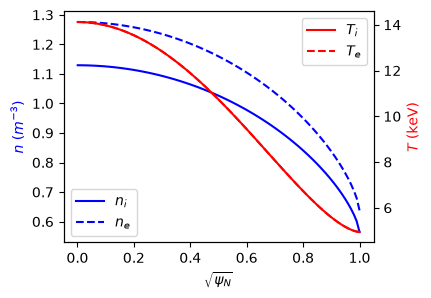

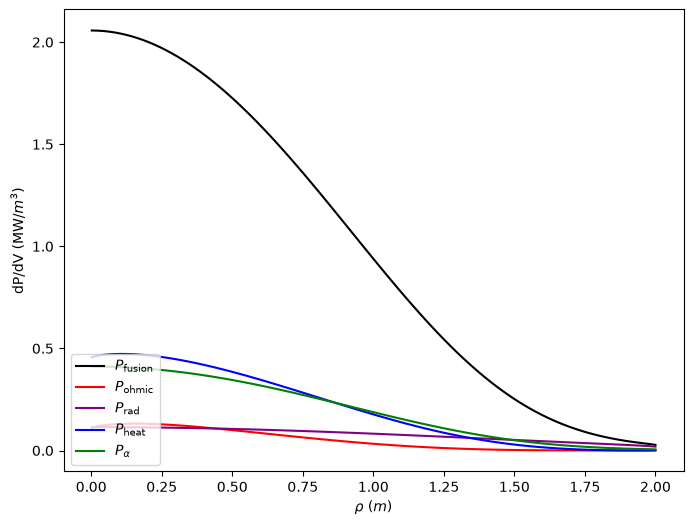

In [5]:
pc.single_point(n_G_frac=0.85, Ti_av=8.5)

## Plotting against different axes

Either axis takes any density or temperature label, so the same solve can be
drawn with the density on x. The seven names are listed in
`openpopcon.PLOT_AXES` and in the plotsettings file.

['T_e_av', 'T_e_ax', 'T_i_av', 'T_i_ax', 'n20_av', 'n20_ax', 'nG']
Plotting Paux with levels [ 10.  20.  50.  73. 100. 200. 500.] and options ['r', 3, '$P_{aux}$', 12, '%.2d']
Plotting Pfusion with levels [  50.  100.  200.  500. 1000. 2000.] and options ['k', 2, '$P_{fus}$', 12, '%.2d']
Plotting Prad with levels [ 10.  50. 100. 200.] and options ['purple', 2, '$P_{rad}$', 12, '%.2d']
Plotting Q with levels [  1.   2.   5.  10.  20.  50. 100.] and options ['orange', 2, '$Q$', 12, '%.f']
Plotting H98 with levels [0.99  0.995 1.    1.005 1.01 ] and options ['blue', 2, '$H_{98y2}$', 12, '%.1f']
Plotting betaN with levels [1.  1.8 2.5 3. ] and options ['forestgreen', 2, '$\\beta_N$', 12, '%.2f']


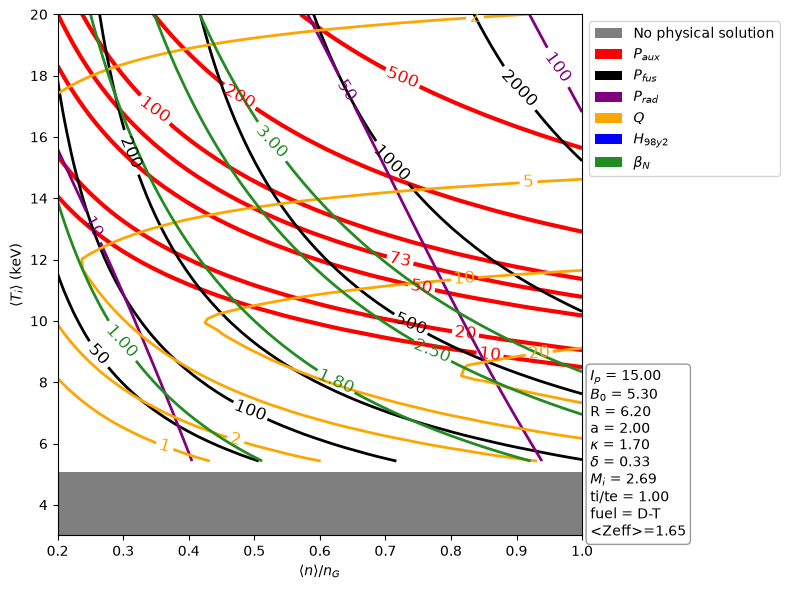

In [6]:
print(sorted(op.PLOT_AXES))

pc.plotsettings.xax = "nG"
pc.plotsettings.yax = "T_i_av"
fig, ax = pc.plot()

pc.plotsettings.xax = "T_i_av"
pc.plotsettings.yax = "nG"

## Scanning the current and the confinement factor

`POPCON_scan` runs a full POPCON at every combination of two machine
parameters. The ranges below come from the `scan:` block at the bottom of the
settings file; passing `scan=` to the constructor overrides it.

In [7]:
sc = op.POPCON_scan(settingsfile=settingsfile, plotsettingsfile=plotsettingsfile)
sc.run_scan()

Impurity fractions = [0.025     0.0079697 0.        0.        0.        0.       ] calculated from Zeff_target.
  [1/9] I_P=10, H_fac=0.8  2500/2500 points solved  (0.6 s)
  [2/9] I_P=10, H_fac=1  2400/2500 points solved  (0.6 s)
  [3/9] I_P=10, H_fac=1.2  2300/2500 points solved  (0.6 s)
  [4/9] I_P=13.5, H_fac=0.8  2350/2500 points solved  (0.9 s)
  [5/9] I_P=13.5, H_fac=1  2218/2500 points solved  (0.7 s)
  [6/9] I_P=13.5, H_fac=1.2  2088/2500 points solved  (0.8 s)
  [7/9] I_P=17, H_fac=0.8  2220/2500 points solved  (0.7 s)
  [8/9] I_P=17, H_fac=1  2052/2500 points solved  (0.9 s)
  [9/9] I_P=17, H_fac=1.2  1873/2500 points solved  (1.7 s)


In [ ]:
fig, axs = sc.plot()

`plot_metric` reduces each cell to one number so the trend across the scan
reads at a glance. Anything in the output works, with any reduction.

In [ ]:
fig, ax = sc.plot_metric("Pfusion", reduce="max")

The whole scan is also available as one xarray Dataset, with the two scanned
parameters as extra dimensions, for any analysis the plots do not cover.

In [ ]:
sc.output